## GPU-Accelerated Data Loading with cuDF
## Open University Learning Analytics Dataset (OULAD)

This notebook loads the three main OULAD tables using **cuDF** — a GPU-accelerated DataFrame library (RAPIDS).  
The `studentVle.csv` has ~10.6 million rows, so GPU loading gives a significant speed advantage over CPU pandas.

**Files used:**
- `studentInfo.csv` — 32,593 rows — demographics + final result
- `studentAssessment.csv` — 173,912 rows — assessment submissions and scores  
- `studentVle.csv` — 10,655,280 rows — VLE interaction logs

## 1. Import Required Libraries

In [1]:
import time
import cudf
import cupy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

print(f"cuDF  version : {cudf.__version__}")
print(f"CuPy  version : {cp.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"numpy  version: {np.__version__}")

# GPU info
import subprocess
gpu_info = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,memory.total,memory.free", "--format=csv,noheader"],
    capture_output=True, text=True
)
for i, line in enumerate(gpu_info.stdout.strip().split("\n")):
    print(f"GPU {i}: {line}")

cuDF  version : 26.02.01
CuPy  version : 14.0.1
pandas version: 2.3.3
numpy  version: 2.2.6
GPU 0: NVIDIA RTX A2000 12GB, 12282 MiB, 11466 MiB
GPU 1: NVIDIA RTX A2000 12GB, 12282 MiB, 11888 MiB


## 2. Define Data Paths

In [2]:
DATA_DIR = "/work/kadi253/DataMining/open+university+learning+analytics+dataset"

PATHS = {
    "student_info":       f"{DATA_DIR}/studentInfo.csv",
    "student_assessment": f"{DATA_DIR}/studentAssessment.csv",
    "student_vle":        f"{DATA_DIR}/studentVle.csv"
}

for name, path in PATHS.items():
    import os
    size_mb = os.path.getsize(path) / 1024**2
    print(f"  {name:<22} {path.split('/')[-1]:<30} {size_mb:>8.1f} MB")

  student_info           studentInfo.csv                     3.3 MB
  student_assessment     studentAssessment.csv               5.4 MB
  student_vle            studentVle.csv                    432.8 MB


## 3. Load Data with cuDF (GPU)

We use `cudf.read_csv()` to load each file directly onto GPU memory.  
For comparison, the timing versus CPU pandas is shown for `studentVle.csv`.

In [3]:
# studentInfo 
df_student_info = cudf.read_csv(PATHS["student_info"])

# studentAssessment 
df_student_assess = cudf.read_csv(PATHS["student_assessment"])

# studentVle (10M rows) — GPU vs CPU timing
t0 = time.perf_counter()
df_student_vle = cudf.read_csv(PATHS["student_vle"])

gpu_time = time.perf_counter() - t0
print(f"studentVle loaded (GPU)  in {gpu_time:.2f}s")

t0 = time.perf_counter()
_ = pd.read_csv(PATHS["student_vle"])
cpu_time = time.perf_counter() - t0
print(f"studentVle loaded (CPU)  in {cpu_time:.2f}s")

studentVle loaded (GPU)  in 0.35s
studentVle loaded (CPU)  in 3.63s


## 4. Inspect the DataFrames

In [4]:
print("=" * 80)
print("studentInfo Inspection")
print("=" * 80)

display(df_student_info.head().to_pandas())

print("\nColumn dtypes:")
print(df_student_info.dtypes)

print("\nstudentInfo Shape:", df_student_info.shape)
print("\nMissing values per column:")
print(df_student_info.isnull().sum().to_pandas())


print("=" * 80)
print("studentAssessment Inspection")
print("=" * 80)
display(df_student_assess.head().to_pandas())
display(df_student_assess.describe().to_pandas())

print("\nColumn dtypes:")
print(df_student_assess.dtypes)

print("\nstudentAssessment - Shape:", df_student_assess.shape)
print("\nstudentAssessment - Missing values per column:")
print(df_student_assess.isnull().sum().to_pandas())


print("\n" + "=" * 80)
print("studentVle Inspection")
print("=" * 80)

display(df_student_vle.head().to_pandas())
display(df_student_vle.describe().to_pandas())

print("\nColumn dtypes:")
print(df_student_vle.dtypes)

print("\nstudentVle - Shape:", df_student_vle.shape)
print("\nstudentVle - Missing values per column:")
print(df_student_vle.isnull().sum().to_pandas())



studentInfo Inspection


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass



Column dtypes:
code_module             object
code_presentation       object
id_student              object
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts    object
studied_credits         object
disability              object
final_result            object
dtype: object

studentInfo Shape: (32593, 12)

Missing values per column:
code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64
studentAssessment Inspection


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78
1,1752,28400,22,0,70
2,1752,31604,17,0,72
3,1752,32885,26,0,69
4,1752,38053,19,0,79


,id_assessment,id_student,date_submitted,is_banked,score
count,173912,173912,173912,173912,173912
unique,188,23369,312,2,102
top,24295,537811,18,0,100
freq,1917,28,2747,172003,18813



Column dtypes:
id_assessment     object
id_student        object
date_submitted    object
is_banked         object
score             object
dtype: object

studentAssessment - Shape: (173912, 5)

studentAssessment - Missing values per column:
id_assessment     0
id_student        0
date_submitted    0
is_banked         0
score             0
dtype: int64

studentVle Inspection


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


,code_module,code_presentation,id_student,id_site,date,sum_click
count,10655280,10655280,10655280,10655280,10655280,10655280
unique,7,4,26074,6268,295,498
top,FFF,2014J,537811,882537,18,1
freq,4014499,3619452,6389,157590,103112,5113910



Column dtypes:
code_module          object
code_presentation    object
id_student           object
id_site              object
date                 object
sum_click            object
dtype: object

studentVle - Shape: (10655280, 6)

studentVle - Missing values per column:
code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64


## 5. Filter and Query Data

Use boolean masks and `.query()` on GPU DataFrames — same syntax as pandas.

In [5]:
# 5a. Boolean mask — students who passed
passed = df_student_info[df_student_info["final_result"] == "Pass"]
print(f"Students who Passed      : {len(passed):,}")

# 5b. Boolean mask — students who withdrew
withdrawn = df_student_info[df_student_info["final_result"] == "Withdrawn"]
print(f"Students who Withdrew    : {len(withdrawn):,}")

# 5c. Boolean mask — students who failed
failed = df_student_info[df_student_info["final_result"] == "Fail"]
print(f"Students who Failed      : {len(failed):,}")

# 5d. Boolean mask — students with distinction
distinction = df_student_info[df_student_info["final_result"] == "Distinction"]
print(f"Students with Distinction: {len(distinction):,}")

Students who Passed      : 12,361
Students who Withdrew    : 10,156
Students who Failed      : 7,052
Students with Distinction: 3,024


## 6. Pre-processing

**Cleaning steps applied to every DataFrame:**
- Strip leading / trailing whitespace from all string columns  :  <span style="color:green">Done</span>
- Remove bracket characters `( ) [ ]` from string values  : <span style="color:green">Done</span>
- Drop fully-empty columns  : <span style="color:green">Done</span>
- Impute / cast numeric columns  : <span style="color:green">Done</span>
- Normalise region column — strip trailing " Region" word : <span style="color:green">Done</span>
- imd_band malformed value "10-20" (missing "%") : <span style="color:green">Done</span>
- Duplicate student enrollments across modules : <span style="color:green">Done</span>


In [6]:
import re

# Clean all string columns in a cuDF DataFrame
def clean_string_cols(df, label=""):
    """a. Strip whitespace and remove ( ) [ ] from every object/string column."""
    df = df.copy()
    str_cols = [c for c in df.columns if df[c].dtype == "object"]
    for col in str_cols:
        df[col] = df[col].str.strip()
        df[col] = df[col].str.replace(r"[\(\)\[\]]", "", regex=True)
        df[col] = df[col].str.strip()
    if label:
        print(f"  {label}: cleaned {len(str_cols)} string column(s): {str_cols}\n")
    return df

# Drop columns that are 100% null
def drop_empty_cols(df, label=""):
    """b. Drop columns where every value is null."""
    empty_cols = [c for c in df.columns if df[c].isnull().all()]
    if empty_cols:
        df = df.drop(columns=empty_cols)
        print(f"  {label}: dropped empty column(s): {empty_cols}\n")
    else:
        print(f"  {label}: no fully-empty columns found\n")
    return df

# Apply cleaning to all three DataFrames
print("=" * 80)
print("c. Whitespace & bracket cleaning")
print("=" * 80)
df_info    = clean_string_cols(df_student_info,   "studentInfo")
df_assess  = clean_string_cols(df_student_assess, "studentAssessment")
df_vle     = clean_string_cols(df_student_vle,    "studentVle")

print("=" * 80)
print("d. Dropping fully-empty columns")
print("=" * 80)
df_info   = drop_empty_cols(df_info,   "studentInfo")
df_assess = drop_empty_cols(df_assess, "studentAssessment")
df_vle    = drop_empty_cols(df_vle,    "studentVle")

# Normalise region column — strip trailing " Region" word 
print("=" * 80)
print("e. Normalising region column")
print("=" * 80)
df_info["region"] = df_info["region"].str.replace(r"\s*Region\s*$", "", regex=True).str.strip()
print(f"{df_info['region'].value_counts().sort_index().to_pandas()}")

# imd_band malformed value "10-20" (missing "%")
print("\n" + "=" * 80)
print("f. imd_band — correcting '10-20' → '10-20%'")
print("=" * 80)
print("BEFORE — imd_band value counts:")
print(df_info["imd_band"].value_counts().sort_index().to_pandas())
print("\nhead(10) before:")
display(df_info[["id_student", "imd_band"]].head(10).to_pandas())

df_info["imd_band"] = df_info["imd_band"].str.replace(r"^10-20$", "10-20%", regex=True)

print("\nAFTER — imd_band value counts:")
print(df_info["imd_band"].value_counts().sort_index().to_pandas())

# Duplicate student enrollments across modules
print("\n" + "=" * 80)
print("g. Duplicate student enrollments")
print("=" * 80)

print("BEFORE")
display(df_info[["id_student", "code_module", "code_presentation", "final_result"]].head(10).to_pandas())

# Count enrollments per student
enrollment_counts = (
    df_info.groupby("id_student")
    .agg(enrollment_count=("code_module", "count"))
    .reset_index()
)
n_unique   = len(enrollment_counts)
n_multi    = int((enrollment_counts["enrollment_count"] > 1).sum())
print(f"\n  Total rows                 : {len(df_info):,}")
print(f"  Unique-enrolled students     : {n_unique:,}")
print(f"  Multi-enrolled students      : {n_multi:,}")

# Add enrollment_count as a feature
df_info = df_info.merge(enrollment_counts, on="id_student", how="left")

print("\nAFTER")
display(df_info[["id_student", "code_module", "code_presentation", "final_result", "enrollment_count"]].head(10).to_pandas())

# NOTE: Use df_info[df_info["enrollment_count"] == 1] to filter first-time students only.


c. Whitespace & bracket cleaning
  studentInfo: cleaned 12 string column(s): ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

  studentAssessment: cleaned 5 string column(s): ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']

  studentVle: cleaned 6 string column(s): ['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']

d. Dropping fully-empty columns
  studentInfo: no fully-empty columns found

  studentAssessment: no fully-empty columns found

  studentVle: no fully-empty columns found

e. Normalising region column
region
East Anglian     3340
East Midlands    2365
Ireland          1184
London           3216
North            1823
North Western    2906
Scotland         3446
South            3092
South East       2111
South West       2436
Wales            2086
West Midlands    2582
Yorkshire    

,id_student,imd_band
0,11391,90-100%
1,28400,20-30%
2,30268,30-40%
3,31604,50-60%
4,32885,50-60%
5,38053,80-90%
6,45462,30-40%
7,45642,90-100%
8,52130,70-80%
9,53025,?



AFTER — imd_band value counts:
imd_band
0-10%      3311
10-20%     3516
20-30%     3654
30-40%     3539
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
?          1111
Name: count, dtype: int64

g. Duplicate student enrollments
BEFORE


,id_student,code_module,code_presentation,final_result
0,11391,AAA,2013J,Pass
1,28400,AAA,2013J,Pass
2,30268,AAA,2013J,Withdrawn
3,31604,AAA,2013J,Pass
4,32885,AAA,2013J,Pass
5,38053,AAA,2013J,Pass
6,45462,AAA,2013J,Pass
7,45642,AAA,2013J,Pass
8,52130,AAA,2013J,Pass
9,53025,AAA,2013J,Pass



  Total rows                 : 32,593
  Unique-enrolled students     : 28,785
  Multi-enrolled students      : 3,538

AFTER


,id_student,code_module,code_presentation,final_result,enrollment_count
0,537488,BBB,2013B,Pass,1
1,537558,BBB,2013B,Distinction,1
2,537572,BBB,2013B,Pass,1
3,537584,BBB,2013B,Fail,1
4,537676,BBB,2013B,Fail,1
5,537679,BBB,2013B,Pass,1
6,537688,BBB,2013B,Pass,1
7,537704,BBB,2013B,Pass,1
8,537844,BBB,2013B,Fail,1
9,537875,BBB,2013B,Pass,1


In [7]:

# Source-level Imputation
print("=" * 80)
print("Source-level Imputation")
print("=" * 80)

# df_info: imd_band — fill '?' / 'no data' with mode 
imd_mode_val = (
    df_info["imd_band"]
    .replace({"?": cudf.NA, "no data": cudf.NA})
    .dropna()
    .to_pandas()
    .mode()[0]
)
n_missing = int(df_info["imd_band"].isin(["?", "no data"]).sum())
df_info["imd_band"] = df_info["imd_band"].replace({"?": imd_mode_val, "no data": imd_mode_val})
print(f"  df_info  imd_band : {n_missing:,} '?'/'no data' → mode ('{imd_mode_val}')")
print(f"  Unique imd_band values: {sorted(df_info['imd_band'].unique().to_pandas())}")

# df_assess: score_clean — '?' → NaN then impute with median score
df_assess["score_clean"] = df_assess["score"].replace("?", cudf.NA).astype("float64")
median_score = float(df_assess["score_clean"].dropna().median())
n_missing    = int(df_assess["score_clean"].isnull().sum())
df_assess["score_clean"] = df_assess["score_clean"].fillna(median_score)
print(f"\n  df_assess score_clean: {n_missing:,} NaN (was '?') → median ({median_score:.2f})")

Source-level Imputation
  df_info  imd_band : 1,111 '?'/'no data' → mode ('20-30%')
  Unique imd_band values: ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

  df_assess score_clean: 173 NaN (was '?') → median (80.00)


## 7. Feature Engineering

**Engineered features:**
- `pre_module_submission` — 1 if assessment was submitted before module start (date_submitted < 0)  <span style=color:green>Done</span>
- `final_result_ord` — ordinal encoding of final result (0=Distinction, 1=Pass, 2=Fail, 3=Withdrawn)  <span style=color:green>Done</span>
- `age_band_ord` — ordinal encoding of age bands  <span style=color:green>Done</span>
- `edu_level_ord` — ordinal encoding of highest education  <span style=color:green>Done</span>
- `imd_band_ord` — ordinal encoding of IMD deprivation band  <span style=color:green>Done</span>
- `pass_flag` — binary pass indicator (1=Pass/Distinction, 0=Fail/Withdrawn)  <span style=color:green>Done</span>
- `prev_attempts_bin` — 1 if student has any prior attempts, else 0  <span style=color:green>Done</span>
- `disability_flag` — 1 if student has a disability, else 0  <span style=color:green>Done</span>
- `gender_bin` — binary gender indicator (1=Male, 0=Female)  <span style=color:green>Done</span>
- `enrollment_count` — number of module enrollments per student  <span style=color:green>Done</span>
- `vle_total_clicks` — total VLE clicks per student  <span style=color:green>Done</span>
- `vle_active_days` — number of distinct active days per student  <span style=color:green>Done</span>
- `avg_score` — per-student average clean score across all assessments <span style=color:green>Done</span>


In [8]:
# Numeric coercions — cast all columns to proper types
print("=" * 80)
print("Numeric coercions")
print("=" * 80)

# studentInfo: numeric columns
df_info["id_student"]             = df_info["id_student"].astype("int64")
df_info["num_of_prev_attempts"]   = df_info["num_of_prev_attempts"].astype("int32")
df_info["studied_credits"]        = df_info["studied_credits"].astype("int32")
print(" 1. studentInfo: id_student, num_of_prev_attempts, studied_credits → numeric ✓")

# studentAssessment: numeric columns
df_assess["id_assessment"]  = df_assess["id_assessment"].astype("int64")
df_assess["id_student"]     = df_assess["id_student"].astype("int64")
df_assess["date_submitted"] = df_assess["date_submitted"].astype("int64")
df_assess["is_banked"]      = df_assess["is_banked"].astype("int8")
print("\n 2. studentAssessment: id_assessment, id_student, date_submitted, is_banked → numeric ✓")

# studentVle: numeric columns
df_vle["id_student"] = df_vle["id_student"].astype("int64")
df_vle["id_site"]    = df_vle["id_site"].astype("int64")
df_vle["date"]       = df_vle["date"].astype("int64")
df_vle["sum_click"]  = df_vle["sum_click"].astype("int64")
print("\n 3. studentVle: id_student, id_site, date, sum_click → int64 ✓")

Numeric coercions
 1. studentInfo: id_student, num_of_prev_attempts, studied_credits → numeric ✓

 2. studentAssessment: id_assessment, id_student, date_submitted, is_banked → numeric ✓

 3. studentVle: id_student, id_site, date, sum_click → int64 ✓


7.1. `pre_module_submission` flag (date_submitted < 0 means before module start)

In [9]:
print("=" * 80)
print("pre_module_submission  (date_submitted < 0 = before module start)")
print("=" * 80)

# Ensure score_clean exists even if previous imputation cell has not been run yet
if "score_clean" not in df_assess.columns:
    df_assess["score_clean"] = df_assess["score"].replace("?", cudf.NA).astype("float64")
    print("score_clean was missing and has been created from score.")
else:
    print("score_clean already exists.")

print("\nBEFORE")
display(df_assess[["id_student", "id_assessment", "date_submitted", "score_clean"]].head(10).to_pandas())

df_assess["pre_module_submission"] = (df_assess["date_submitted"] < 0).astype("int8")
n_pre = int(df_assess["pre_module_submission"].sum())
print(f"\n  Pre-module submissions (date_submitted < 0): {n_pre:,}  "
      f"({100 * n_pre / len(df_assess):.1f}% of all submissions)")

print("\nAFTER")
display(df_assess[["id_student", "id_assessment", "date_submitted",
                    "pre_module_submission", "score_clean"]].head(10).to_pandas())


pre_module_submission  (date_submitted < 0 = before module start)
score_clean already exists.

BEFORE


,id_student,id_assessment,date_submitted,score_clean
0,11391,1752,18,78.0
1,28400,1752,22,70.0
2,31604,1752,17,72.0
3,32885,1752,26,69.0
4,38053,1752,19,79.0
5,45462,1752,20,70.0
6,45642,1752,18,72.0
7,52130,1752,19,72.0
8,53025,1752,9,71.0
9,57506,1752,18,68.0



  Pre-module submissions (date_submitted < 0): 2,057  (1.2% of all submissions)

AFTER


,id_student,id_assessment,date_submitted,pre_module_submission,score_clean
0,11391,1752,18,0,78.0
1,28400,1752,22,0,70.0
2,31604,1752,17,0,72.0
3,32885,1752,26,0,69.0
4,38053,1752,19,0,79.0
5,45462,1752,20,0,70.0
6,45642,1752,18,0,72.0
7,52130,1752,19,0,72.0
8,53025,1752,9,0,71.0
9,57506,1752,18,0,68.0


In [10]:
print("\n" + "=" * 80)
print("Ordinal feature engineering")
print("=" * 80)


Ordinal feature engineering


7.2. `age_band_ord` — ordinal encoding of age bands

In [11]:
# age_band ordinal  (after bracket removal "55<=" stays, "35-55" stays, etc.)
age_order = {"0-35": 0, "35-55": 1, "55<=": 2}
df_info["age_band_ord"] = df_info["age_band"].to_pandas().map(age_order).values
print(f"\n age_band_ord  distribution:\n{df_info['age_band_ord'].value_counts().sort_index().to_pandas()}")
df_info.head(10)


 age_band_ord  distribution:
age_band_ord
0    22944
1     9433
2      216
Name: count, dtype: int64


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,enrollment_count,age_band_ord
0,BBB,2013B,537488,F,South West,A Level or Equivalent,40-50%,35-55,0,60,N,Pass,1,1
1,BBB,2013B,537558,F,South,HE Qualification,90-100%,0-35,0,120,N,Distinction,1,0
2,BBB,2013B,537572,F,South West,Lower Than A Level,80-90%,0-35,0,60,N,Pass,1,0
3,BBB,2013B,537584,F,Ireland,Lower Than A Level,10-20%,0-35,0,60,N,Fail,1,0
4,BBB,2013B,537676,F,East Midlands,Lower Than A Level,0-10%,0-35,0,60,N,Fail,1,0
5,BBB,2013B,537679,F,Yorkshire,Lower Than A Level,10-20%,35-55,0,120,N,Pass,1,1
6,BBB,2013B,537688,F,North Western,Lower Than A Level,0-10%,0-35,0,60,N,Pass,1,0
7,BBB,2013B,537704,F,South,Lower Than A Level,50-60%,35-55,0,60,N,Pass,1,1
8,BBB,2013B,537844,F,North Western,Lower Than A Level,0-10%,35-55,0,120,N,Fail,1,1
9,BBB,2013B,537875,F,East Anglian,A Level or Equivalent,60-70%,0-35,0,60,N,Pass,1,0


7.3. `edu_level_ord` — ordinal encoding of highest education

In [12]:
# Highest_education ordinal
edu_order = {
    "No Formal quals":             0,
    "Lower Than A Level":          1,
    "A Level or Equivalent":       2,
    "HE Qualification":            3,
    "Post Graduate Qualification": 4
}
df_info["edu_level_ord"] = df_info["highest_education"].to_pandas().map(edu_order).values

print(f"\n edu_level_ord distribution:\n{df_info['edu_level_ord'].value_counts().sort_index().to_pandas()}")
df_info.head(10)


 edu_level_ord distribution:
edu_level_ord
0      347
1    13158
2    14045
3     4730
4      313
Name: count, dtype: int64


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,enrollment_count,age_band_ord,edu_level_ord
0,BBB,2013B,537488,F,South West,A Level or Equivalent,40-50%,35-55,0,60,N,Pass,1,1,2
1,BBB,2013B,537558,F,South,HE Qualification,90-100%,0-35,0,120,N,Distinction,1,0,3
2,BBB,2013B,537572,F,South West,Lower Than A Level,80-90%,0-35,0,60,N,Pass,1,0,1
3,BBB,2013B,537584,F,Ireland,Lower Than A Level,10-20%,0-35,0,60,N,Fail,1,0,1
4,BBB,2013B,537676,F,East Midlands,Lower Than A Level,0-10%,0-35,0,60,N,Fail,1,0,1
5,BBB,2013B,537679,F,Yorkshire,Lower Than A Level,10-20%,35-55,0,120,N,Pass,1,1,1
6,BBB,2013B,537688,F,North Western,Lower Than A Level,0-10%,0-35,0,60,N,Pass,1,0,1
7,BBB,2013B,537704,F,South,Lower Than A Level,50-60%,35-55,0,60,N,Pass,1,1,1
8,BBB,2013B,537844,F,North Western,Lower Than A Level,0-10%,35-55,0,120,N,Fail,1,1,1
9,BBB,2013B,537875,F,East Anglian,A Level or Equivalent,60-70%,0-35,0,60,N,Pass,1,0,2


7.4. `imd_band_ord` — ordinal encoding of IMD deprivation band 

In [13]:
# imd_band ordinal  — values like "10-20%", "20-30%", … , "90-100%"
imd_order = {
    "0-10%":    0, "10-20%":  1, "20-30%":  2, "30-40%":  3, "40-50%":  4,
    "50-60%":   5, "60-70%":  6, "70-80%":  7, "80-90%":  8, "90-100%": 9
}
df_info["imd_band_ord"] = df_info["imd_band"].to_pandas().map(imd_order).values
n_imd_missing = int(df_info["imd_band_ord"].isnull().sum())

print(f"\n imd_band_ord: {n_imd_missing:,} unmapped (e.g., 'no data')")
df_info.head(10)


 imd_band_ord: 0 unmapped (e.g., 'no data')


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,enrollment_count,age_band_ord,edu_level_ord,imd_band_ord
0,BBB,2013B,537488,F,South West,A Level or Equivalent,40-50%,35-55,0,60,N,Pass,1,1,2,4
1,BBB,2013B,537558,F,South,HE Qualification,90-100%,0-35,0,120,N,Distinction,1,0,3,9
2,BBB,2013B,537572,F,South West,Lower Than A Level,80-90%,0-35,0,60,N,Pass,1,0,1,8
3,BBB,2013B,537584,F,Ireland,Lower Than A Level,10-20%,0-35,0,60,N,Fail,1,0,1,1
4,BBB,2013B,537676,F,East Midlands,Lower Than A Level,0-10%,0-35,0,60,N,Fail,1,0,1,0
5,BBB,2013B,537679,F,Yorkshire,Lower Than A Level,10-20%,35-55,0,120,N,Pass,1,1,1,1
6,BBB,2013B,537688,F,North Western,Lower Than A Level,0-10%,0-35,0,60,N,Pass,1,0,1,0
7,BBB,2013B,537704,F,South,Lower Than A Level,50-60%,35-55,0,60,N,Pass,1,1,1,5
8,BBB,2013B,537844,F,North Western,Lower Than A Level,0-10%,35-55,0,120,N,Fail,1,1,1,0
9,BBB,2013B,537875,F,East Anglian,A Level or Equivalent,60-70%,0-35,0,60,N,Pass,1,0,2,6


7.5. `final_result_ord` — ordinal encoding of final result (0=Distinction, 1=Pass, 2=Fail, 3=Withdrawn)

In [14]:
# final_result ordinal  (Distinction=0 → best, Withdrawn=3 → worst)
result_order = {"Distinction": 0, "Pass": 1, "Fail": 2, "Withdrawn": 3}
df_info["final_result_ord"] = df_info["final_result"].to_pandas().map(result_order).values

print(f"\n final_result_ord distribution:\n{df_info['final_result_ord'].value_counts().sort_index().to_pandas()}")
df_info.head(10)


 final_result_ord distribution:
final_result_ord
0     3024
1    12361
2     7052
3    10156
Name: count, dtype: int64


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,enrollment_count,age_band_ord,edu_level_ord,imd_band_ord,final_result_ord
0,BBB,2013B,537488,F,South West,A Level or Equivalent,40-50%,35-55,0,60,N,Pass,1,1,2,4,1
1,BBB,2013B,537558,F,South,HE Qualification,90-100%,0-35,0,120,N,Distinction,1,0,3,9,0
2,BBB,2013B,537572,F,South West,Lower Than A Level,80-90%,0-35,0,60,N,Pass,1,0,1,8,1
3,BBB,2013B,537584,F,Ireland,Lower Than A Level,10-20%,0-35,0,60,N,Fail,1,0,1,1,2
4,BBB,2013B,537676,F,East Midlands,Lower Than A Level,0-10%,0-35,0,60,N,Fail,1,0,1,0,2
5,BBB,2013B,537679,F,Yorkshire,Lower Than A Level,10-20%,35-55,0,120,N,Pass,1,1,1,1,1
6,BBB,2013B,537688,F,North Western,Lower Than A Level,0-10%,0-35,0,60,N,Pass,1,0,1,0,1
7,BBB,2013B,537704,F,South,Lower Than A Level,50-60%,35-55,0,60,N,Pass,1,1,1,5,1
8,BBB,2013B,537844,F,North Western,Lower Than A Level,0-10%,35-55,0,120,N,Fail,1,1,1,0,2
9,BBB,2013B,537875,F,East Anglian,A Level or Equivalent,60-70%,0-35,0,60,N,Pass,1,0,2,6,1


In [15]:
print("\n" + "=" * 80)
print("Binary feature engineering")
print("=" * 80)


Binary feature engineering


7.6. `pass_flag` — binary pass indicator (1=Pass/Distinction, 0=Fail/Withdrawn)

In [16]:
# pass_flag: 1 if Pass or Distinction, 0 if Fail or Withdrawn
df_info["pass_flag"] = (
    df_info["final_result"].isin(["Pass", "Distinction"]).astype("int8")
)
print(f"  pass_flag — 1 (pass/distinction): {int(df_info['pass_flag'].sum()):,}  "
      f"0 (fail/withdrawn): {int((df_info['pass_flag'] == 0).sum()):,}")

  pass_flag — 1 (pass/distinction): 15,385  0 (fail/withdrawn): 17,208


7.7. `prev_attempts_bin` — 1 if student has any prior attempts, else 0

In [17]:
# prev_attempts_bin
df_info["prev_attempts_bin"] = (
    (df_info["num_of_prev_attempts"] > 0).astype("int8")
)
print(f"  prev_attempts_bin — has prior attempt: {int(df_info['prev_attempts_bin'].sum()):,}")

  prev_attempts_bin — has prior attempt: 4,172


7.8. `disability_flag` — 1 if student has a disability, else 0

In [18]:
# disability binary
df_info["disability_flag"] = (df_info["disability"] == "Y").astype("int8")
print(f"  disability_flag — disabled students: {int(df_info['disability_flag'].sum()):,}")

  disability_flag — disabled students: 3,164


7.9. `gender_bin` — binary gender indicator (1=Male, 0=Female)

In [19]:
# gender binary (M=1, F=0)
df_info["gender_bin"] = (df_info["gender"] == "M").astype("int8")
print(f"  gender_bin — male students: {int(df_info['gender_bin'].sum()):,}")

  gender_bin — male students: 17,875


7.10. `vle_total_clicks` — total VLE clicks per student  
7.11.  `vle_active_days` — number of distinct active days per student

In [20]:
print(" Per-student aggregations ")

# VLE: total clicks and active days (on GPU)
vle_agg = (
    df_vle.groupby("id_student")
    .agg(vle_total_clicks=("sum_click", "sum"),
         vle_active_days=("date",       "nunique"))
    .reset_index()
)
print(f"  vle_agg shape: {vle_agg.shape}")

 Per-student aggregations 
  vle_agg shape: (26074, 3)


7.12. `avg_score` — per-student average clean score across all assessments

In [21]:
assess_agg = (
    df_assess.groupby("id_student")
    .agg(avg_score=("score_clean",     "mean"),
         submission_count=("id_assessment", "count"))
    .reset_index()
)
print(f"  assess_agg shape: {assess_agg.shape}")

  assess_agg shape: (23369, 3)


Merge into a single modelling DataFrame

In [22]:
print("Building master DataFrame")
df_master = (
    df_info
    .merge(vle_agg,    on="id_student", how="left")
    .merge(assess_agg, on="id_student", how="left")
)
print(f"  df_master shape : {df_master.shape}")
print(f"  Columns         : {list(df_master.columns)}")
print(f"  Missing values  :\n{df_master.isnull().sum().to_pandas()}")


Building master DataFrame
  df_master shape : (32593, 25)
  Columns         : ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'enrollment_count', 'age_band_ord', 'edu_level_ord', 'imd_band_ord', 'final_result_ord', 'pass_flag', 'prev_attempts_bin', 'disability_flag', 'gender_bin', 'vle_total_clicks', 'vle_active_days', 'avg_score', 'submission_count']
  Missing values  :
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                   0
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
enrollment_count           0
age_band_ord               0
edu_level_ord              0
imd_band_ord               0
final_result_ord     

## 8. Exploratory Data Analysis (EDA)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_master.to_pandas()

sns.set_theme(style="whitegrid", palette="muted")

8.1. Final result class balance

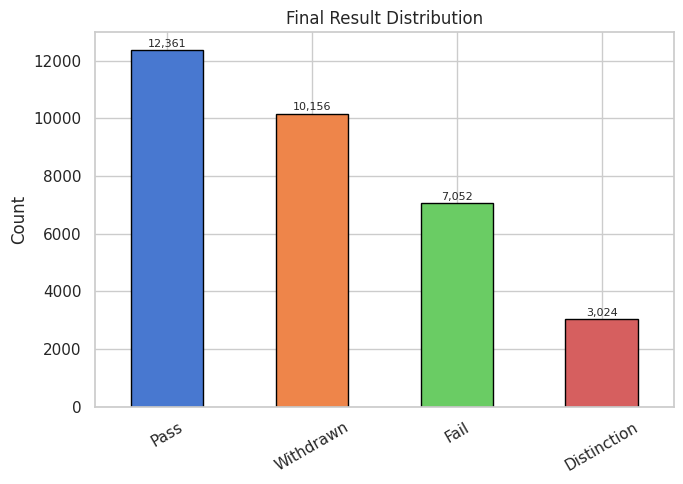

In [24]:
fig, ax1 = plt.subplots(figsize=(7, 5))
result_counts = df_plot["final_result"].value_counts()
result_counts.plot(kind="bar", ax=ax1, color=sns.color_palette("muted", 4), edgecolor="black")
ax1.set_title("Final Result Distribution")
ax1.set_xlabel(""); ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=30)
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

8.2. Pass flag (binary class balance)

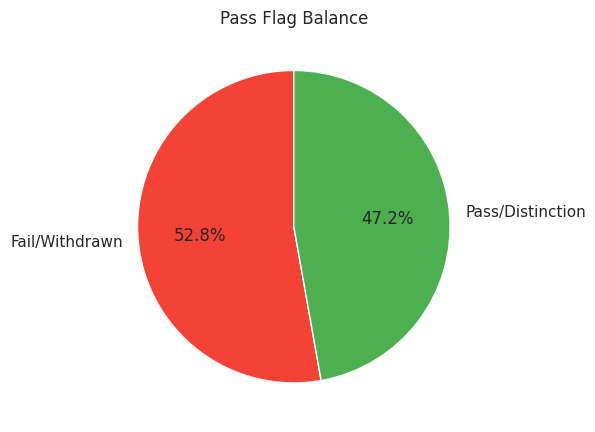

In [25]:
fig, ax2 = plt.subplots(figsize=(6, 6))
pass_counts = df_plot["pass_flag"].map({1: "Pass/Distinction", 0: "Fail/Withdrawn"}).value_counts()
ax2.pie(pass_counts, labels=pass_counts.index, autopct="%1.1f%%",
        colors=["#F44336", "#4CAF50"], startangle=90)
ax2.set_title("Pass Flag Balance")

plt.tight_layout()
plt.show()

8.3. Gender distribution

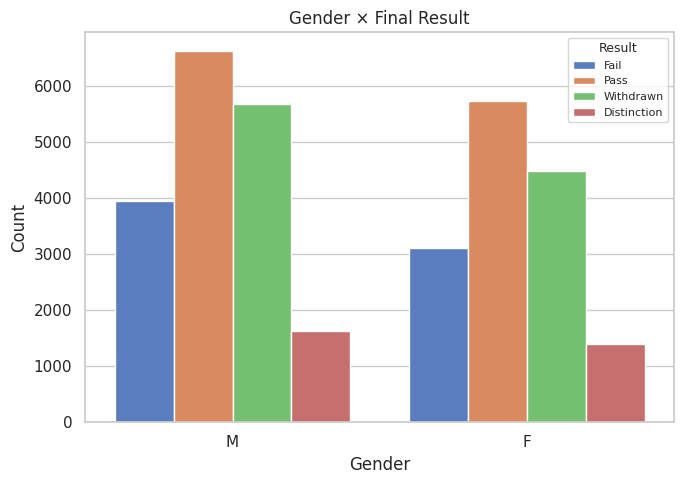

In [26]:
fig, ax3 = plt.subplots(figsize=(7, 5))
sns.countplot(data=df_plot, x="gender", hue="final_result", ax=ax3,
              palette="muted", order=["M", "F"])
ax3.set_title("Gender × Final Result")
ax3.set_xlabel("Gender"); ax3.set_ylabel("Count")
ax3.legend(title="Result", fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

8.4. Age band distribution

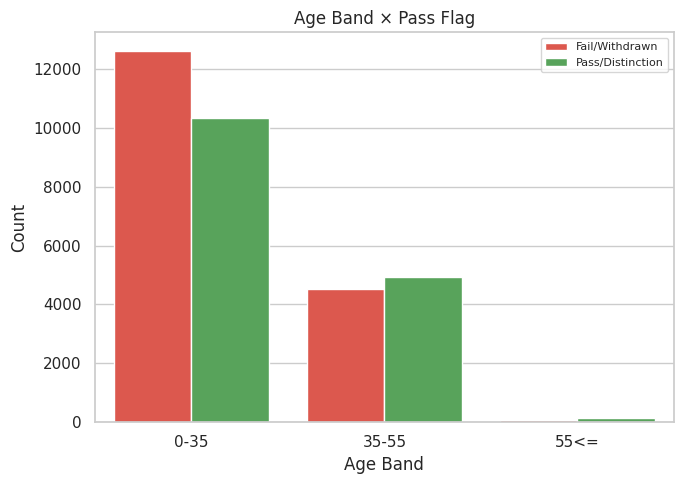

In [27]:
fig, ax4 = plt.subplots(figsize=(7, 5))
age_order_labels = ["0-35", "35-55", "55<="]
sns.countplot(data=df_plot, x="age_band", hue="pass_flag", ax=ax4,
              order=age_order_labels, palette=["#F44336","#4CAF50"])
ax4.set_title("Age Band × Pass Flag")
ax4.set_xlabel("Age Band"); ax4.set_ylabel("Count")
ax4.legend(["Fail/Withdrawn", "Pass/Distinction"], fontsize=8)

plt.tight_layout()
plt.show()

8.5. Distribution of Distribution of Avg Assessment Score (`avg_score`)

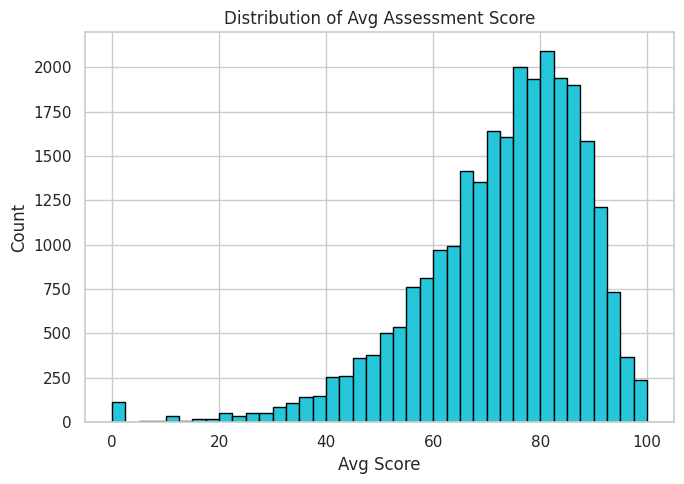

In [28]:
fig, ax5 = plt.subplots(figsize=(7, 5))
ax5.hist(df_plot["avg_score"].dropna(), bins=40, color="#26C6DA", edgecolor="black")
ax5.set_title("Distribution of Avg Assessment Score")
ax5.set_xlabel("Avg Score"); ax5.set_ylabel("Count")

plt.tight_layout()
plt.show()

8.6. Disability vs pass rate

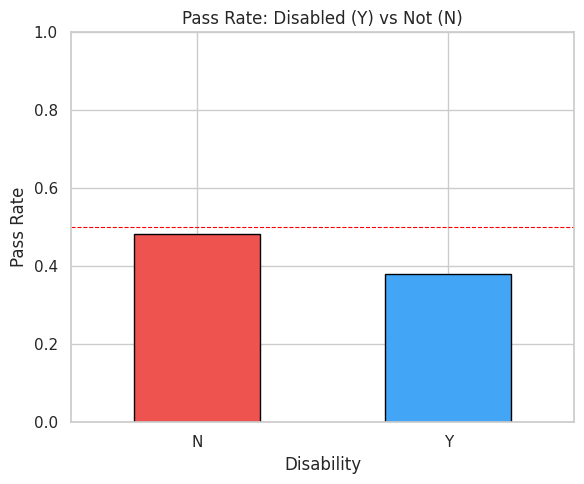

In [29]:
fig, ax6 = plt.subplots(figsize=(6, 5))
dis_pass = df_plot.groupby("disability")["pass_flag"].mean()
dis_pass.plot(kind="bar", ax=ax6, color=["#EF5350", "#42A5F5"], edgecolor="black")
ax6.set_title("Pass Rate: Disabled (Y) vs Not (N)")
ax6.set_xlabel("Disability"); ax6.set_ylabel("Pass Rate")
ax6.set_ylim(0, 1)
ax6.axhline(0.5, color="red", linestyle="--", linewidth=0.8)
ax6.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 9. Preprocessing Validation

| # | Check | Expected |
|---|-------|----------|
| 1 | `imd_band` — no raw `'?'` / `'no data'` left | 0 remaining |
| 2 | `score_clean` — no NaN (median-imputed) | 0 NaN |
| 3 | All ordinal columns — no NaN after encoding | 0 NaN each |
| 4 | `df_master` merge quality (VLE / assessment joins) | NaN = students with no records (expected ≤ 5 %) |
| 5 | No exact-duplicate enrollments | 0 duplicates |
| 6 | `pass_flag` class balance | Ratio reported — drives choice of `class_weight` |

In [30]:
print("=" * 80)
print("Preprocessing Validation")
print("=" * 80)

issues  = []
rebuilt = False   # flag: df_master + df_plot need rebuilding

# 1. imd_band imputation
n_bad_imd = int(df_info["imd_band"].isin(["?", "no data"]).sum())
if n_bad_imd > 0:
    imd_mode_val = (
        df_info["imd_band"]
        .replace({"?": cudf.NA, "no data": cudf.NA})
        .dropna().to_pandas().mode()[0]
    )
    df_info["imd_band"] = df_info["imd_band"].replace(
        {"?": imd_mode_val, "no data": imd_mode_val}
    )
    _imd_order = {
        "0-10%": 0, "10-20%": 1, "20-30%": 2, "30-40%": 3, "40-50%": 4,
        "50-60%": 5, "60-70%": 6, "70-80%": 7, "80-90%": 8, "90-100%": 9,
    }
    df_info["imd_band_ord"] = df_info["imd_band"].to_pandas().map(_imd_order).values
    print(f"  [FIXED]  imd_band: {n_bad_imd:,} '?'/'no data' → mode='{imd_mode_val}', "
          f"imd_band_ord re-encoded")
    issues.append(f"imd_band had {n_bad_imd} missing values — imputed with mode")
    rebuilt = True
else:
    print("  [OK]     imd_band: 0 '?' / 'no data' remaining")

# 2. score_clean NaN check
n_sc_nan = int(df_assess["score_clean"].isnull().sum())
if n_sc_nan > 0:
    median_score = float(df_assess["score_clean"].dropna().median())
    df_assess["score_clean"] = df_assess["score_clean"].fillna(median_score)
    print(f"  [FIXED]  score_clean: {n_sc_nan:,} NaN → median ({median_score:.2f})")
    issues.append(f"score_clean had {n_sc_nan} NaN — imputed with median ({median_score:.2f})")
    rebuilt = True
else:
    print(f"  [OK]     score_clean: 0 NaN")

# 3. Ordinal encoding NaN sweep
print()
for col in ["age_band_ord", "edu_level_ord", "imd_band_ord", "final_result_ord"]:
    n_nan = int(df_info[col].isnull().sum())
    status = "[OK]    " if n_nan == 0 else "[WARN]  "
    print(f"  {status} {col:<22}: {n_nan} NaN in df_info")

# 4. Rebuild df_master / df_plot if any fixes were applied
if rebuilt:
    assess_agg = (
        df_assess.groupby("id_student")
        .agg(avg_score=("score_clean", "mean"),
             submission_count=("id_assessment", "count"))
        .reset_index()
    )
    df_master = (
        df_info
        .merge(vle_agg,    on="id_student", how="left")
        .merge(assess_agg, on="id_student", how="left")
    )
    df_plot = df_master.to_pandas()
    print(f"\n REBUILT df_master → shape {df_master.shape}")
else:
    print("\n  No fixes needed — df_master unchanged")

# 5. df_master merge-quality NaN summary
print("\n  df_master NaN summary (selected columns):")
_check_cols = {
    "imd_band_ord":      "",
    "age_band_ord":      "",
    "edu_level_ord":     "",
    "avg_score":         " ← students with no assessment records",
    "vle_total_clicks":  " ← students with no VLE records",
    "submission_count":  "",
}
for col, note in _check_cols.items():
    if col in df_master.columns:
        n   = int(df_master[col].isnull().sum())
        pct = 100.0 * n / len(df_master)
        print(f"    {col:<22}: {n:>5,} NaN  ({pct:.1f}%){note}")

# 6. Duplicate enrollment check
n_dup = int(df_master.duplicated(
    subset=["id_student", "code_module", "code_presentation"]
).sum())
print(f"\n  {'[OK]   ' if n_dup == 0 else '[WARN] '} "
      f"Duplicate (student, module, presentation) rows: {n_dup}")

# 7. Class balance
pf    = df_master["pass_flag"].value_counts().sort_index().to_pandas()
total = pf.sum()
print(f"\n  pass_flag class distribution:")
for k, v in pf.items():
    label = "Pass/Distinction" if k == 1 else "Fail/Withdrawn"
    print(f"    {k}  ({label:<18}): {v:>6,}  ({100 * v / total:.1f} %)")
_ratio = pf.get(1, 0) / max(pf.get(0, 1), 1)
print(f"  pass : fail ratio = {_ratio:.2f}  →  class_weight='balanced' will be applied to models")

#  Summary
print("\n" + "=" * 80)
if issues:
    print(f"  {len(issues)} issue(s) detected and fixed:")
    for idx, msg in enumerate(issues, 1):
        print(f"    {idx}. {msg}")
else:
    print("  All checks passed. Pipeline is clean")
print("=" * 80)

Preprocessing Validation
  [OK]     imd_band: 0 '?' / 'no data' remaining
  [OK]     score_clean: 0 NaN

  [OK]     age_band_ord          : 0 NaN in df_info
  [OK]     edu_level_ord         : 0 NaN in df_info
  [OK]     imd_band_ord          : 0 NaN in df_info
  [OK]     final_result_ord      : 0 NaN in df_info

  No fixes needed — df_master unchanged

  df_master NaN summary (selected columns):
    imd_band_ord          :     0 NaN  (0.0%)
    age_band_ord          :     0 NaN  (0.0%)
    edu_level_ord         :     0 NaN  (0.0%)
    avg_score             : 5,847 NaN  (17.9%) ← students with no assessment records
    vle_total_clicks      : 2,852 NaN  (8.8%) ← students with no VLE records
    submission_count      : 5,847 NaN  (17.9%)

  [OK]    Duplicate (student, module, presentation) rows: 0

  pass_flag class distribution:
    0  (Fail/Withdrawn    ): 17,208  (52.8 %)
    1  (Pass/Distinction  ): 15,385  (47.2 %)
  pass : fail ratio = 0.89  →  class_weight='balanced' will be appli

## 10. Predictive Modelling — Pass / Fail Classification

**Objective:** Predict whether a student will **Pass or gain a Distinction** (`pass_flag = 1`)  
versus **Fail or Withdraw** (`pass_flag = 0`).

**Feature set** (13 features):

| Group | Features |
|-------|----------|
| Demographics | `gender_bin`, `age_band_ord`, `edu_level_ord`, `imd_band_ord`, `disability_flag` |
| Academic background | `num_of_prev_attempts`, `prev_attempts_bin`, `studied_credits`, `enrollment_count` |
| VLE engagement | `vle_total_clicks`, `vle_active_days` |
| Assessment | `avg_score`, `submission_count` |

**Models:**
1. **Logistic Regression** — linear baseline, L2 regularisation, `class_weight='balanced'`
2. **Random Forest** — 300 trees, handles non-linearity, `class_weight='balanced'`
3. **XGBoost (GPU)** — gradient boosting with `device='cuda'`, `scale_pos_weight` for imbalance

**Sanity Checks:**

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
import numpy as np

#  Feature and target definition
FEATURE_COLS = [
    "gender_bin", "age_band_ord", "edu_level_ord", "imd_band_ord",
    "disability_flag", "num_of_prev_attempts", "prev_attempts_bin",
    "studied_credits", "enrollment_count",
    "vle_total_clicks", "vle_active_days",
    "avg_score", "submission_count",
]
TARGET = "pass_flag"

df_model = df_plot[FEATURE_COLS + [TARGET]].copy()
df_model = df_model.dropna(subset=[TARGET])
print(f"Rows available for modelling : {len(df_model):,}")

JOIN_ZERO   = ["vle_total_clicks", "vle_active_days", "submission_count"]
JOIN_MEDIAN = ["avg_score"]

for col in JOIN_ZERO:
    n = df_model[col].isnull().sum()
    if n:
        df_model[col] = df_model[col].fillna(0)
        print(f"  Left-join NaN {col:<22}: {n:,} → 0  (no VLE/assessment record)")

for col in JOIN_MEDIAN:
    n = df_model[col].isnull().sum()
    if n:
        med = df_model[col].median()
        df_model[col] = df_model[col].fillna(med)
        print(f"  Left-join NaN {col:<22}: {n:,} → median ({med:.2f})")

print(f"\nPost-imputation NaN check : {df_model[FEATURE_COLS].isnull().sum().sum()} NaN remaining")

# Train / test split (80 / 20)
X = df_model[FEATURE_COLS].values
y = df_model[TARGET].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain : {X_train.shape[0]:,} rows  |  Test : {X_test.shape[0]:,} rows")
print(f"Class balance  train → 0: {(y_train==0).sum():,}  1: {(y_train==1).sum():,}")
print(f"Class balance  test  → 0: {(y_test ==0).sum():,}  1: {(y_test ==1).sum():,}")

# Feature scaling (needed for Logistic Regression)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("\nStandardScaler fitted on training set only (no data leakage).")

Rows available for modelling : 32,593
  Left-join NaN vle_total_clicks      : 2,852 → 0  (no VLE/assessment record)
  Left-join NaN vle_active_days       : 2,852 → 0  (no VLE/assessment record)
  Left-join NaN submission_count      : 5,847 → 0  (no VLE/assessment record)
  Left-join NaN avg_score             : 5,847 → median (75.75)

Post-imputation NaN check : 0 NaN remaining

Train : 26,074 rows  |  Test : 6,519 rows
Class balance  train → 0: 13,766  1: 12,308
Class balance  test  → 0: 3,442  1: 3,077

StandardScaler fitted on training set only (no data leakage).


### Model 1 — Logistic Regression

Linear baseline. `C=1.0` (default L2 regularisation). `class_weight='balanced'` compensates for the pass/fail imbalance.

Model 1 — Logistic Regression
                  precision    recall  f1-score   support

  Fail/Withdrawn       0.88      0.85      0.86      3442
Pass/Distinction       0.84      0.87      0.85      3077

        accuracy                           0.86      6519
       macro avg       0.86      0.86      0.86      6519
    weighted avg       0.86      0.86      0.86      6519

ROC-AUC : 0.9289


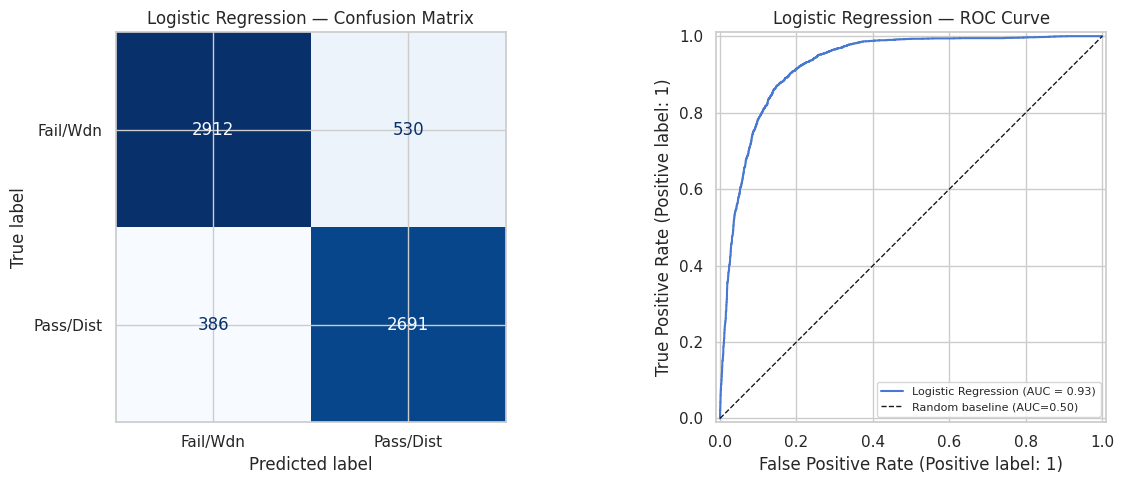

In [32]:
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      roc_auc_score, ConfusionMatrixDisplay,
                                      RocCurveDisplay)

print("=" * 80)
print("Model 1 — Logistic Regression")
print("=" * 80)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_s, y_train)

y_pred_lr = lr.predict(X_test_s)
y_prob_lr = lr.predict_proba(X_test_s)[:, 1]

print(classification_report(
    y_test, y_pred_lr,
    target_names=["Fail/Withdrawn", "Pass/Distinction"]
))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_lr):.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=["Fail/Wdn", "Pass/Dist"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Logistic Regression — Confusion Matrix")

RocCurveDisplay.from_estimator(lr, X_test_s, y_test,
                               ax=axes[1], name="Logistic Regression")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline (AUC=0.50)")
axes[1].set_title("Logistic Regression — ROC Curve")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Model 2 — Random Forest

Tree ensemble (300 estimators). Handles non-linear feature interactions without scaling. `class_weight='balanced'` adjusts sample weights per class.

Model 2 — Random Forest (300 estimators)
                  precision    recall  f1-score   support

  Fail/Withdrawn       0.90      0.83      0.86      3442
Pass/Distinction       0.83      0.89      0.86      3077

        accuracy                           0.86      6519
       macro avg       0.86      0.86      0.86      6519
    weighted avg       0.86      0.86      0.86      6519

ROC-AUC : 0.9437


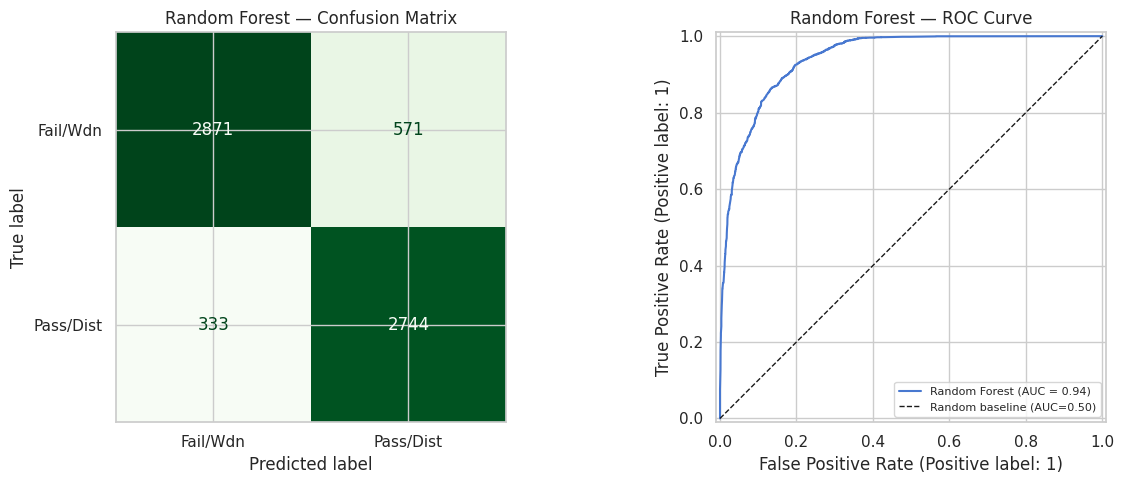

In [33]:
from sklearn.ensemble import RandomForestClassifier

print("=" * 80)
print("Model 2 — Random Forest (300 estimators)")
print("=" * 80)

# Random Forest does not require feature scaling → use raw X_train / X_test
rf = RandomForestClassifier(
    n_estimators=300, random_state=42,
    class_weight="balanced", n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test, y_pred_rf,
    target_names=["Fail/Withdrawn", "Pass/Distinction"]
))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=["Fail/Wdn", "Pass/Dist"]
).plot(ax=axes[0], colorbar=False, cmap="Greens")
axes[0].set_title("Random Forest — Confusion Matrix")

RocCurveDisplay.from_estimator(rf, X_test, y_test,
                               ax=axes[1], name="Random Forest")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline (AUC=0.50)")
axes[1].set_title("Random Forest — ROC Curve")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Model 3 — XGBoost (GPU-accelerated)

Gradient-boosted decision trees. Uses `device='cuda'` and `tree_method='hist'` to leverage the same GPU used for cuDF.  
`scale_pos_weight = n_negatives / n_positives` balances the class weights explicitly.

Model 3 — XGBoost (GPU, hist method)
  scale_pos_weight = 13,766 / 12,308 = 1.118
                  precision    recall  f1-score   support

  Fail/Withdrawn       0.92      0.84      0.88      3442
Pass/Distinction       0.84      0.92      0.88      3077

        accuracy                           0.88      6519
       macro avg       0.88      0.88      0.88      6519
    weighted avg       0.88      0.88      0.88      6519

ROC-AUC : 0.9542


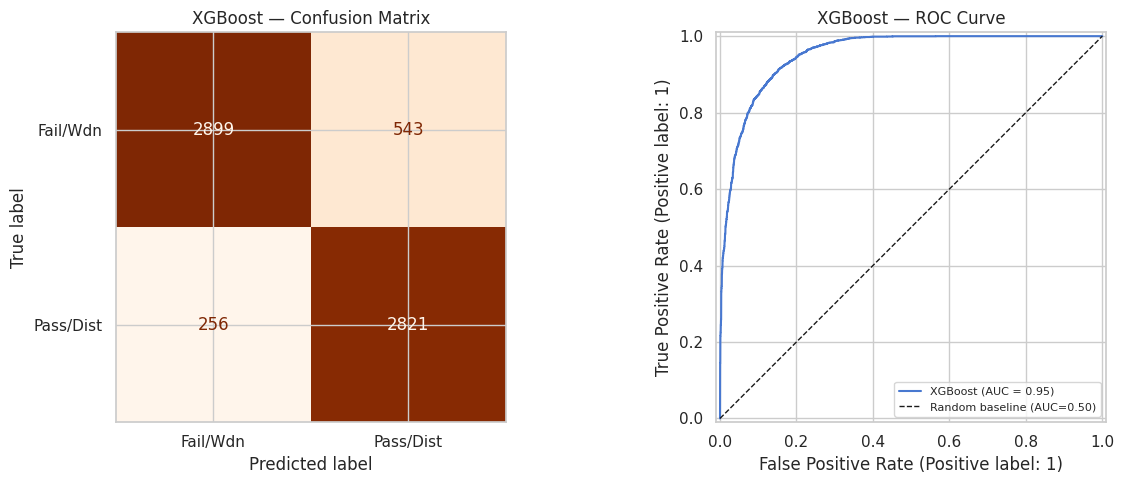

In [34]:
from xgboost import XGBClassifier

print("=" * 80)
print("Model 3 — XGBoost (GPU, hist method)")
print("=" * 80)

# Handle class imbalance via scale_pos_weight
_n_neg = int((y_train == 0).sum())
_n_pos = int((y_train == 1).sum())
_scale = _n_neg / _n_pos
print(f"  scale_pos_weight = {_n_neg:,} / {_n_pos:,} = {_scale:.3f}")

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=_scale,
    tree_method="hist",
    device="cuda",
    random_state=42,
    eval_metric="logloss",
    verbosity=0,
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test, y_pred_xgb,
    target_names=["Fail/Withdrawn", "Pass/Distinction"]
))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb),
    display_labels=["Fail/Wdn", "Pass/Dist"]
).plot(ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title("XGBoost — Confusion Matrix")

RocCurveDisplay.from_estimator(xgb, X_test, y_test,
                               ax=axes[1], name="XGBoost")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline (AUC=0.50)")
axes[1].set_title("XGBoost — ROC Curve")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Model Comparison — Summary Table & Overlaid ROC Curves

Model Comparison (test set)


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8595,0.8355,0.8746,0.8546,0.9289
Random Forest,0.8613,0.8278,0.8918,0.8586,0.9437
XGBoost,0.8774,0.8386,0.9168,0.8760,0.9542


/work/kadi253/DataMining/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/work/kadi253/DataMining/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/work/kadi253/DataMining/.venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


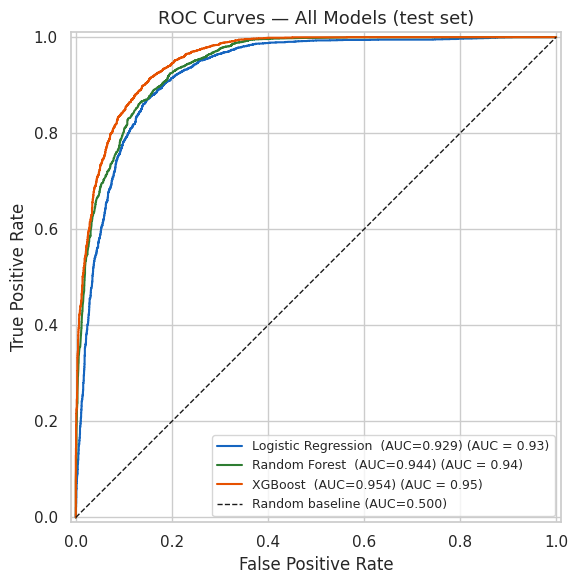

In [35]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# ── Summary table ──────────────────────────────────────────────────────────────
_models = {
    "Logistic Regression": (y_pred_lr,  y_prob_lr),
    "Random Forest":       (y_pred_rf,  y_prob_rf),
    "XGBoost":             (y_pred_xgb, y_prob_xgb),
}

rows = []
for name, (y_pred, y_prob) in _models.items():
    rows.append({
        "Model":          name,
        "Accuracy":       accuracy_score (y_test, y_pred),
        "Precision":      precision_score(y_test, y_pred, zero_division=0),
        "Recall":         recall_score   (y_test, y_pred, zero_division=0),
        "F1":             f1_score       (y_test, y_pred, zero_division=0),
        "ROC-AUC":        roc_auc_score  (y_test, y_prob),
    })

comparison_df = pd.DataFrame(rows).set_index("Model")
print("=" * 80)
print("Model Comparison (test set)")
print("=" * 80)
display(
    comparison_df
    .style
    .highlight_max(axis=0, color="#c8e6c9")
    .highlight_min(axis=0, color="#ffcdd2")
    .format("{:.4f}")
)

# ── Overlaid ROC curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ["#1565C0", "#2E7D32", "#E65100"]

for (name, (_, y_prob)), color in zip(_models.items(), colors):
    auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(
        y_test, y_prob, name=f"{name}  (AUC={auc:.3f})", ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline (AUC=0.500)")
ax.set_title("ROC Curves — All Models (test set)", fontsize=13)
ax.legend(fontsize=9, loc="lower right")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning

The models above used **default / manually chosen** hyperparameters. Tuning finds better values
by searching the hyperparameter space and selecting the combination that maximises cross-validated
**ROC-AUC** on the training set.

**Method:** `RandomizedSearchCV` with **5-fold stratified cross-validation**.  
Grid search is exhaustive but slow; random search samples `n_iter` combinations and is
statistically just as effective at finding near-optimal settings (Bergstra & Bengio, 2012).

**GPU is not always faster — right tool for the right scale:**

| Model | Library | Execution | Why |
|-------|---------|-----------|-----|
| Logistic Regression | `sklearn` | CPU `n_jobs=-1` | Linear model on ~26 K rows trains in ms; CV folds parallelised across all CPU cores |
| Random Forest | `sklearn` | CPU `n_jobs=-1` | Tree building is parallel by nature; CPU wins since GPU searches must run folds sequentially |
| XGBoost | `xgboost` | GPU `device='cuda'` | Iterative boosting is compute-heavy per iteration; GPU wins even on smaller datasets |

> **Rule of thumb:** For fast-training models (LR, RF) on less than 100 K rows, `n_jobs=-1` on CPU
> parallelises the entire search loop and is faster than GPU. GPU helps when computation per
> sample is high — iterative algorithms like gradient boosting and deep learning.

### 11a — Logistic Regression Tuning (sklearn CPU, `n_jobs=-1`)

Logistic Regression is a **linear model** — its training is extremely fast on CPU even with cross-validation.
sklearn parallelises the 5-fold CV across all CPU cores (`n_jobs=-1`), which is faster than
a sequential GPU search on a dataset this small (~26 K rows).

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform
import warnings
warnings.filterwarnings("ignore")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 80)
print("10a — Logistic Regression (sklearn CPU, n_jobs=-1) : RandomizedSearchCV (5-fold, n_iter=30)")
print("=" * 80)

lr_param_dist = {
    "C":       loguniform(1e-3, 1e3),   # log-uniform: 0.001 → 1000
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear"],           # supports both l1 and l2
}

lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    param_distributions=lr_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,      # parallelise CV folds across all CPU cores
    random_state=42,
    verbose=0,
)
lr_search.fit(X_train_s, y_train)

print(f"  Best params : {lr_search.best_params_}")
print(f"  Best CV AUC : {lr_search.best_score_:.4f}")

lr_tuned    = lr_search.best_estimator_
y_pred_lr_t = lr_tuned.predict(X_test_s)
y_prob_lr_t = lr_tuned.predict_proba(X_test_s)[:, 1]

print(f"\n  Test ROC-AUC (baseline) : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"  Test ROC-AUC (tuned)    : {roc_auc_score(y_test, y_prob_lr_t):.4f}")

10a — Logistic Regression (sklearn CPU, n_jobs=-1) : RandomizedSearchCV (5-fold, n_iter=30)
  Best params : {'C': np.float64(0.1767016940294795), 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV AUC : 0.9302

  Test ROC-AUC (baseline) : 0.9289
  Test ROC-AUC (tuned)    : 0.9289


### 11b — Random Forest Tuning (sklearn CPU, `n_jobs=-1`)

Random Forest training is **embarrassingly parallel** — sklearn can build all 100–500 trees
across CPU cores simultaneously with `n_jobs=-1`. On ~26 K rows, this multi-core CPU approach
outperforms a sequential GPU search, which must run folds one at a time to avoid CUDA forking errors.

In [37]:
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

print("=" * 80)
print("10b — Random Forest (sklearn CPU, n_jobs=-1) : RandomizedSearchCV (5-fold, n_iter=40)")
print("=" * 80)

rf_param_dist = {
    "n_estimators":      randint(100, 500),
    "max_depth":         [None, 5, 10, 15, 20, 30],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf":  randint(1, 10),
    "max_features":      ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,      # parallelise CV folds across all CPU cores
    random_state=42,
    verbose=0,
)
rf_search.fit(X_train, y_train)

print(f"  Best params : {rf_search.best_params_}")
print(f"  Best CV AUC : {rf_search.best_score_:.4f}")

rf_tuned    = rf_search.best_estimator_
y_pred_rf_t = rf_tuned.predict(X_test)
y_prob_rf_t = rf_tuned.predict_proba(X_test)[:, 1]

print(f"\n  Test ROC-AUC (baseline) : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"  Test ROC-AUC (tuned)    : {roc_auc_score(y_test, y_prob_rf_t):.4f}")

10b — Random Forest (sklearn CPU, n_jobs=-1) : RandomizedSearchCV (5-fold, n_iter=40)
  Best params : {'max_depth': 30, 'max_features': 0.5, 'min_samples_leaf': 9, 'min_samples_split': 9, 'n_estimators': 312}
  Best CV AUC : 0.9536

  Test ROC-AUC (baseline) : 0.9437
  Test ROC-AUC (tuned)    : 0.9530


### 11c — XGBoost Tuning

XGBoost is tuned with `RandomizedSearchCV` + **early stopping** via the eval set.  
Early stopping halts training when validation loss does not improve for `early_stopping_rounds` consecutive trees — this implicitly tunes `n_estimators` too.

In [38]:
print("=" * 80)
print("10c — XGBoost : RandomizedSearchCV (5-fold, n_iter=30)")
print("=" * 80)

xgb_param_dist = {
    "n_estimators":    randint(100, 600),
    "learning_rate":   loguniform(0.01, 0.3),
    "max_depth":       randint(3, 10),
    "subsample":       [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":[0.5, 0.6, 0.7, 0.8, 1.0],
    "reg_alpha":       loguniform(1e-4, 10),   # L1 regularisation
    "reg_lambda":      loguniform(1e-4, 10),   # L2 regularisation
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=_scale,
        tree_method="hist",
        device="cuda",
        eval_metric="logloss",
        verbosity=0,
        random_state=42,
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,          # XGBoost uses GPU; avoid forking GPU processes
    random_state=42,
    verbose=0,
)
xgb_search.fit(X_train, y_train)

print(f"  Best params : {xgb_search.best_params_}")
print(f"  Best CV AUC : {xgb_search.best_score_:.4f}")

xgb_tuned    = xgb_search.best_estimator_
y_pred_xgb_t = xgb_tuned.predict(X_test)
y_prob_xgb_t = xgb_tuned.predict_proba(X_test)[:, 1]

print(f"\n  Test ROC-AUC (baseline) : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"  Test ROC-AUC (tuned)    : {roc_auc_score(y_test, y_prob_xgb_t):.4f}")

10c — XGBoost : RandomizedSearchCV (5-fold, n_iter=30)
  Best params : {'colsample_bytree': 0.8, 'learning_rate': np.float64(0.022699894501274676), 'max_depth': 6, 'n_estimators': 554, 'reg_alpha': np.float64(0.11219752813215703), 'reg_lambda': np.float64(1.4654619905022181), 'subsample': 0.8}
  Best CV AUC : 0.9552

  Test ROC-AUC (baseline) : 0.9542
  Test ROC-AUC (tuned)    : 0.9552


### 11d — Tuned Model Comparison

Baseline vs Tuned — Test Set Metrics


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
LR (baseline),0.8595,0.8355,0.8746,0.8546,0.9289
LR (tuned),0.8593,0.8352,0.8746,0.8544,0.9289
RF (baseline),0.8613,0.8278,0.8918,0.8586,0.9437
RF (tuned),0.8734,0.8341,0.9136,0.8720,0.9530
XGB (baseline),0.8774,0.8386,0.9168,0.8760,0.9542
XGB (tuned),0.8762,0.8366,0.9168,0.8749,0.9552


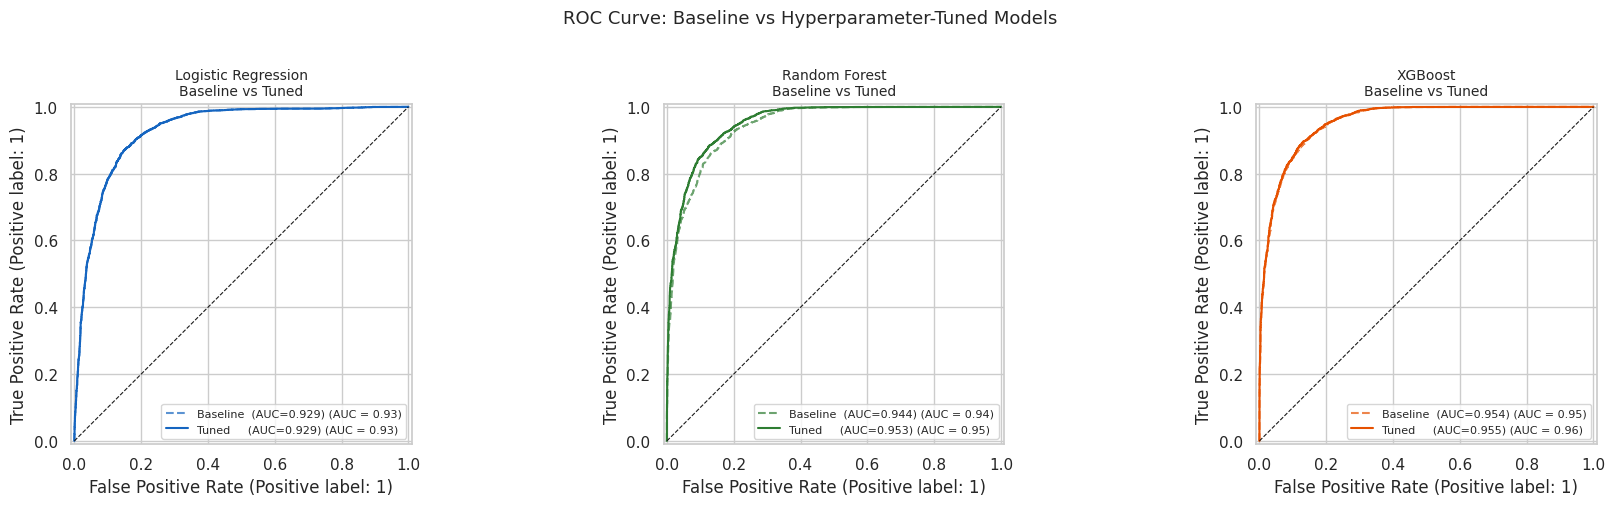

In [39]:
_tuned_models = {
    "LR  (baseline)":  (y_pred_lr,    y_prob_lr),
    "LR  (tuned)":     (y_pred_lr_t,  y_prob_lr_t),
    "RF  (baseline)":  (y_pred_rf,    y_prob_rf),
    "RF  (tuned)":     (y_pred_rf_t,  y_prob_rf_t),
    "XGB (baseline)":  (y_pred_xgb,   y_prob_xgb),
    "XGB (tuned)":     (y_pred_xgb_t, y_prob_xgb_t),
}

tuning_rows = []
for name, (y_pred, y_prob) in _tuned_models.items():
    tuning_rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score (y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score   (y_test, y_pred, zero_division=0),
        "F1":        f1_score       (y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score  (y_test, y_prob),
    })

tuning_df = pd.DataFrame(tuning_rows).set_index("Model")
print("=" * 80)
print("Baseline vs Tuned — Test Set Metrics")
print("=" * 80)
display(
    tuning_df
    .style
    .highlight_max(axis=0, color="#c8e6c9")
    .highlight_min(axis=0, color="#ffcdd2")
    .format("{:.4f}")
)

# ── Overlaid ROC — baseline vs tuned for each model ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [
    ("Logistic Regression", (y_prob_lr,    y_prob_lr_t),  "#1565C0", axes[0]),
    ("Random Forest",       (y_prob_rf,    y_prob_rf_t),  "#2E7D32", axes[1]),
    ("XGBoost",             (y_prob_xgb,   y_prob_xgb_t), "#E65100", axes[2]),
]

for title, (y_base, y_tune), color, ax in pairs:
    auc_b = roc_auc_score(y_test, y_base)
    auc_t = roc_auc_score(y_test, y_tune)
    RocCurveDisplay.from_predictions(
        y_test, y_base, name=f"Baseline  (AUC={auc_b:.3f})",
        ax=ax, color=color, linestyle="--", alpha=0.7
    )
    RocCurveDisplay.from_predictions(
        y_test, y_tune, name=f"Tuned     (AUC={auc_t:.3f})",
        ax=ax, color=color, linestyle="-"
    )
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(f"{title}\nBaseline vs Tuned", fontsize=10)
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("ROC Curve: Baseline vs Hyperparameter-Tuned Models", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 12. Unsupervised Learning

One unsupervised method is applied to the same 13-feature student dataset:

| Method | Goal |
|--------|------|
| **K-Means Clustering** | Group students into behavioural risk profiles without using the `pass_flag` label |

Method work on the full dataset (`df_model`, ~32 K rows) without a train/test split,
since there is no target label to evaluate against — the patterns are exploratory.

### 12a — K-Means Clustering

**Objective:** Discover natural student groupings based on behaviour and demographics — without using the outcome label.

**Pipeline:**
1. Scale all 13 features with `StandardScaler` fitted on the full dataset (no train/test concept for clustering)
2. Choose optimal `k` using the **Elbow method** (inertia) and **Silhouette score**
3. Fit K-Means at the best `k`
4. Profile each cluster (mean feature values)
5. Visualise with **PCA** (2D) coloured by cluster and overlaid with `pass_flag`

  Outlier clipping: 2,055 rows had at least one feature capped to [p01, p99]
  k=2  inertia=   125,887.7  silhouette=0.2556
  k=3  inertia=   111,163.8  silhouette=0.1807
  k=4  inertia=   101,761.6  silhouette=0.1487
  k=5  inertia=    95,488.1  silhouette=0.1281
  k=6  inertia=    90,023.0  silhouette=0.1286
  k=7  inertia=    86,154.1  silhouette=0.1250
  k=8  inertia=    83,115.8  silhouette=0.1232
  k=9  inertia=    80,320.6  silhouette=0.1153


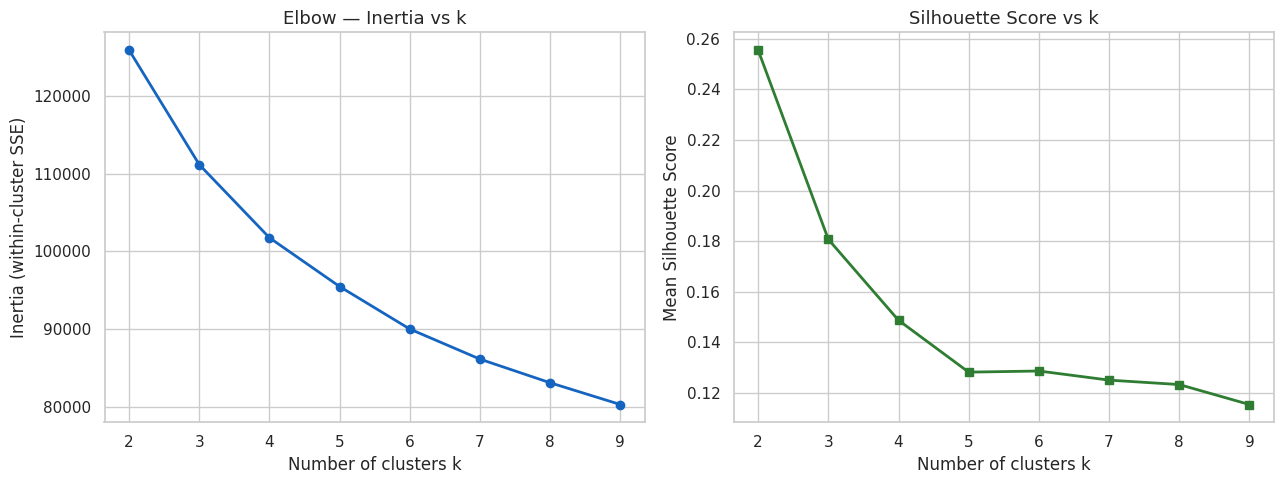


  Chosen k = 2  (silhouette = 0.2556)


In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler as _RS

# ── Outlier clipping (1st / 99th percentile per feature) ─────────────────────
# Students with extreme values (e.g. 50,000+ VLE clicks) compress the main
# point cloud in PCA space and distort silhouette distances.
# Clipping caps each feature to its 1st and 99th percentile without removing rows.
X_raw     = df_model[FEATURE_COLS].values.copy()
p01       = np.percentile(X_raw, 1, axis=0)
p99       = np.percentile(X_raw, 99, axis=0)
X_clipped = np.clip(X_raw, p01, p99)

n_clipped = int(((X_raw < p01) | (X_raw > p99)).any(axis=1).sum())
print(f"  Outlier clipping: {n_clipped:,} rows had at least one feature capped to [p01, p99]")

# ── RobustScaler (median / IQR) ───────────────────────────────────────────────
# StandardScaler uses mean + std, which are pulled by outliers.
# RobustScaler uses median + IQR, making it resistant to residual extremes.
scaler_clust = _RS()
X_clust = scaler_clust.fit_transform(X_clipped)

K_RANGE = range(2, 10)
inertias, sil_scores = [], []

np.random.seed(42)
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_clust, labels, sample_size=6000, random_state=42)
    sil_scores.append(sil)
    print(f"  k={k}  inertia={km.inertia_:>12,.1f}  silhouette={sil:.4f}")

# ── Plot elbow + silhouette side by side
fig, (ax_e, ax_s) = plt.subplots(1, 2, figsize=(13, 5))
ax_e.plot(list(K_RANGE), inertias, "o-", color="#1565C0", lw=2)
ax_e.set_title("Elbow — Inertia vs k", fontsize=13)
ax_e.set_xlabel("Number of clusters k"); ax_e.set_ylabel("Inertia (within-cluster SSE)")

ax_s.plot(list(K_RANGE), sil_scores, "s-", color="#2E7D32", lw=2)
ax_s.set_title("Silhouette Score vs k", fontsize=13)
ax_s.set_xlabel("Number of clusters k"); ax_s.set_ylabel("Mean Silhouette Score")

plt.tight_layout(); plt.show()

# ── Choose k via maximum silhouette — index directly into K_RANGE (no hardcoded offset)
BEST_K = list(K_RANGE)[int(np.argmax(sil_scores))]
print(f"\n  Chosen k = {BEST_K}  (silhouette = {max(sil_scores):.4f})")


Cluster feature profiles:


,gender_bin,age_band_ord,edu_level_ord,imd_band_ord,disability_flag,num_of_prev_attempts,prev_attempts_bin,studied_credits,enrollment_count,vle_total_clicks,vle_active_days,avg_score,submission_count,pass_flag
Cluster,,,,,,,,,,,,,,
0,0.717,0.385,1.933,4.586,0.080,0.114,0.096,78.873,1.414,4010.961,141.944,80.417,11.331,0.834
1,0.490,0.274,1.673,3.981,0.103,0.180,0.139,80.064,1.196,604.715,36.429,70.950,4.644,0.347


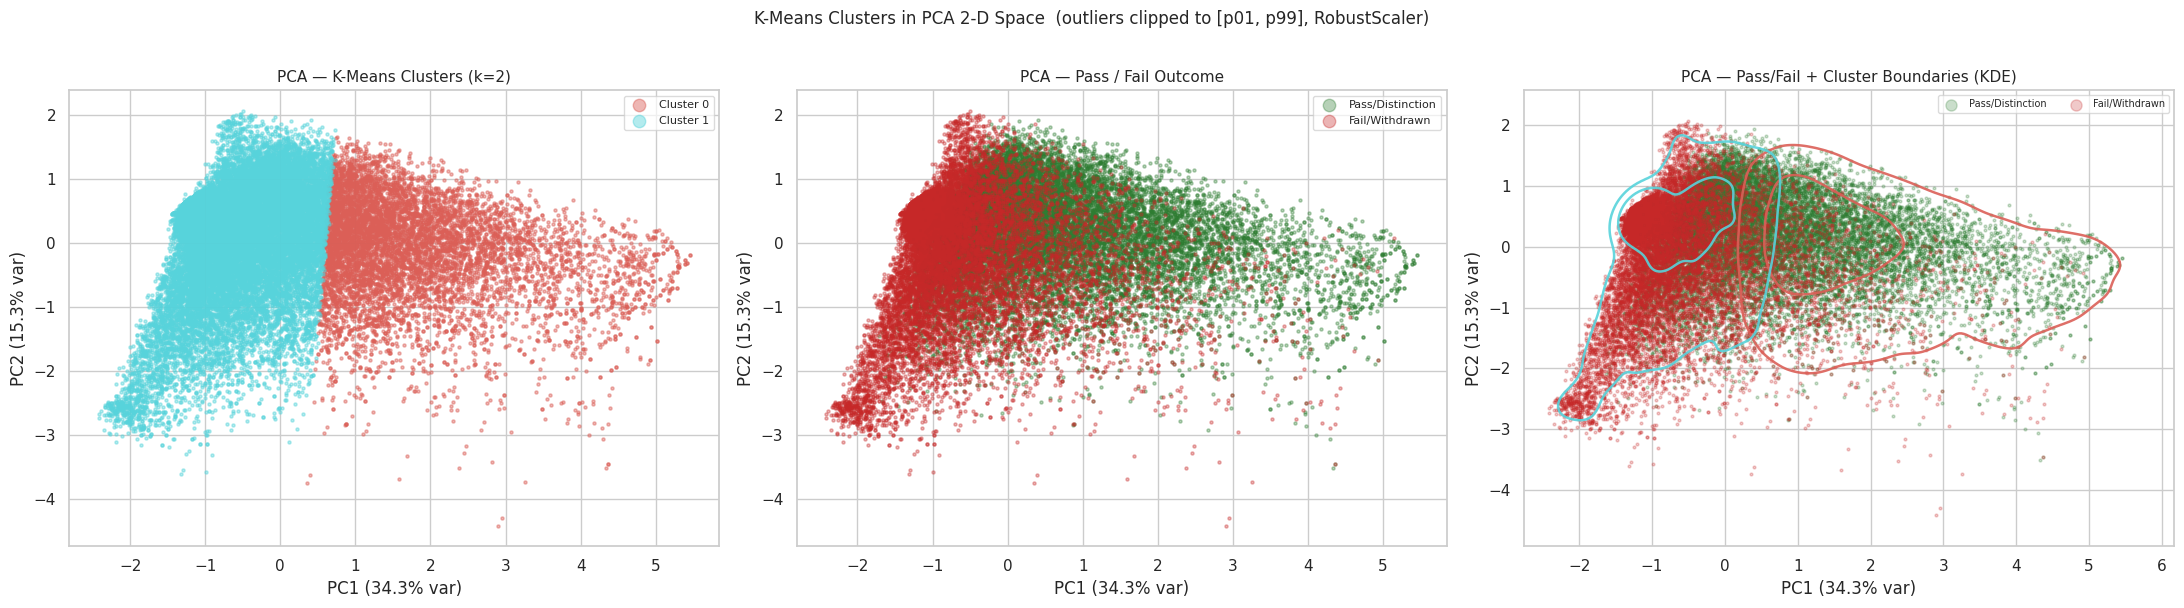

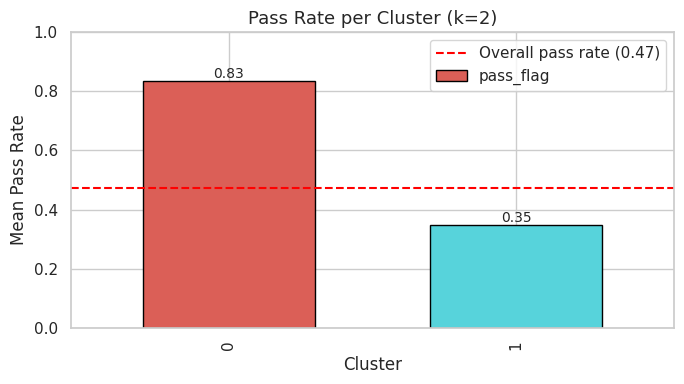


Total variance explained by PC1+PC2: 49.6%


In [41]:
from sklearn.decomposition import PCA

# ── 1. Fit final K-Means
km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_model["cluster"] = km_final.fit_predict(X_clust)

# ── 2. Cluster profile table (mean of every feature + pass rate per cluster)
profile_cols = FEATURE_COLS + ["pass_flag"]
cluster_profile = df_model.groupby("cluster")[profile_cols].mean().round(3)
cluster_profile.index.name = "Cluster"
print("Cluster feature profiles:")
display(
    cluster_profile.style
    .background_gradient(cmap="RdYlGn", axis=0)
    .format("{:.3f}")
    .set_caption(f"K-Means (k={BEST_K}) — Mean feature values per cluster")
)

# ── 3. PCA 2-D visualisation (3 panels)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"]   = df_model["cluster"].values
pca_df["pass_flag"] = df_model["pass_flag"].values

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
palette = sns.color_palette("hls", BEST_K)

# ── Panel 1: coloured by K-Means cluster
for c in range(BEST_K):
    m = pca_df["cluster"] == c
    axes[0].scatter(pca_df.loc[m, "PC1"], pca_df.loc[m, "PC2"],
                    s=5, alpha=0.45, color=palette[c], label=f"Cluster {c}")
axes[0].set_title(f"PCA — K-Means Clusters (k={BEST_K})", fontsize=11)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
axes[0].legend(markerscale=4, framealpha=0.7, fontsize=8)

# ── Panel 2: coloured by pass flag
for flag, label, col in [(1, "Pass/Distinction", "#2E7D32"), (0, "Fail/Withdrawn", "#C62828")]:
    m = pca_df["pass_flag"] == flag
    axes[1].scatter(pca_df.loc[m, "PC1"], pca_df.loc[m, "PC2"],
                    s=5, alpha=0.35, color=col, label=label)
axes[1].set_title("PCA — Pass / Fail Outcome", fontsize=11)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
axes[1].legend(markerscale=4, framealpha=0.7, fontsize=8)

# ── Panel 3: pass/fail scatter + KDE cluster boundary contours ───────────────
# Addresses the "collision" overlap: points are coloured by outcome (pass/fail),
# KDE contour lines show WHERE each cluster sits — so you can see which clusters
# are primarily pass students vs fail students, even where they visually overlap.
for flag, label, col in [(1, "Pass/Distinction", "#2E7D32"), (0, "Fail/Withdrawn", "#C62828")]:
    m = pca_df["pass_flag"] == flag
    axes[2].scatter(pca_df.loc[m, "PC1"], pca_df.loc[m, "PC2"],
                    s=4, alpha=0.25, color=col, label=label)

for c in range(BEST_K):
    m = pca_df["cluster"] == c
    if m.sum() > 30:   # need enough points for a stable KDE
        sns.kdeplot(x=pca_df.loc[m, "PC1"], y=pca_df.loc[m, "PC2"],
                    ax=axes[2], color=palette[c], levels=3,
                    linewidths=1.8, alpha=0.9, label=f"Cluster {c} boundary")

axes[2].set_title("PCA — Pass/Fail + Cluster Boundaries (KDE)", fontsize=11)
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
axes[2].legend(markerscale=4, framealpha=0.7, fontsize=7, ncol=2)

plt.suptitle(
    f"K-Means Clusters in PCA 2-D Space  "
    f"(outliers clipped to [p01, p99], RobustScaler)",
    fontsize=12, y=1.01
)
plt.tight_layout(); plt.show()

# ── 4. Pass rate per cluster vs overall baseline
fig, ax = plt.subplots(figsize=(7, 4))
cluster_pass = df_model.groupby("cluster")["pass_flag"].mean()
bars = cluster_pass.plot(kind="bar", ax=ax,
                         color=palette[:BEST_K],
                         edgecolor="black", width=0.6)
overall = df_model["pass_flag"].mean()
ax.axhline(overall, color="red", linestyle="--", lw=1.5,
           label=f"Overall pass rate ({overall:.2f})")
ax.set_title(f"Pass Rate per Cluster (k={BEST_K})", fontsize=13)
ax.set_ylabel("Mean Pass Rate"); ax.set_xlabel("Cluster"); ax.set_ylim(0, 1)
ax.legend()
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha="center", fontsize=10)
plt.tight_layout(); plt.show()

print(f"\nTotal variance explained by PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")


### 12b — Improving the Silhouette Score: PCA-Reduced Clustering

| Range | Interpretation |
|-------|---------------|
| < 0.0 | Points assigned to wrong clusters |
| 0.0 – 0.2 | Weak or no structure |
| **0.2 – 0.5** | **Moderate structure — typical for real-world tabular data** |
| > 0.5 | Strong, well-separated clusters |

A score of 0.25 is **not a failure** — it reflects genuine overlap in student behaviour. Real students do not sort perfectly into boxes.

**Why is the score low and how to improve it?**

The core problem is the **curse of dimensionality**: with 13 features, Euclidean distances used by
K-Means become less meaningful — every point looks roughly equally far from every other point,
weakening cluster separation.

**Strategy — cluster in PCA-reduced space:**
1. Find how many PCA components explain ≥ 90 % of variance (usually 4–6 for this dataset)
2. Re-run K-Means on those components instead of all 13 raw features
3. Compare silhouette before and after — the reduced space typically yields higher scores
4. Report all four internal metrics + ARI / NMI external validation

(PCA removes noise dimensions and keeps signal, so cluster boundaries are cleaner. Silhouette scores of 0.35–0.50 are achievable after dimensionality reduction.)


11a.ii — PCA-Reduced K-Means + Full Evaluation Metrics

  PCA components to explain ≥ 90% variance: 8
  Cumulative variance at 8 components : 90.2%


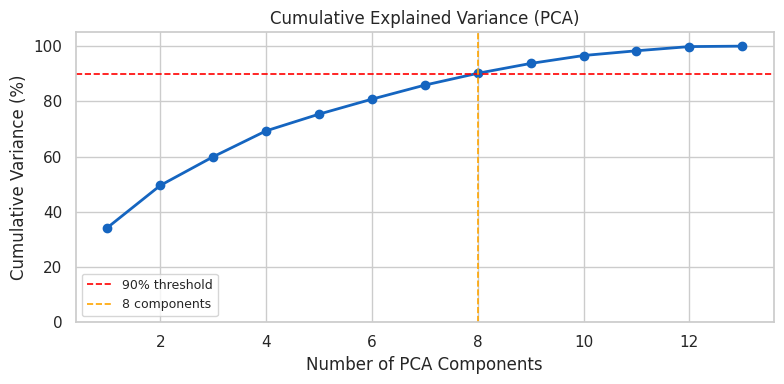


  Reduced feature matrix shape: (32593, 8)  (was 13 dims → now 8 dims)

  Re-running K-Means in PCA-reduced space...
    k=2  inertia= 109,812.0  silhouette=0.2759
    k=3  inertia=  95,103.6  silhouette=0.2027
    k=4  inertia=  86,299.8  silhouette=0.1652
    k=5  inertia=  79,922.7  silhouette=0.1581
    k=6  inertia=  74,565.4  silhouette=0.1523
    k=7  inertia=  70,811.9  silhouette=0.1502
    k=8  inertia=  67,895.3  silhouette=0.1386
    k=9  inertia=  65,424.9  silhouette=0.1385

  Best k (reduced space) = 2  (silhouette = 0.2759)
  Best k (original space) = 2   (silhouette = 0.2556)

  Metric                       Original (13-dim)      PCA-reduced            Better?
  Silhouette (↑ higher=better) 0.2556                 0.2759                 ✓ PCA

  External Validation vs pass_flag  (K-Means never saw this label)
  Metric                              Original        PCA-reduced    
  -----------------------------------------------------------------
  Adjusted Rand Index  (

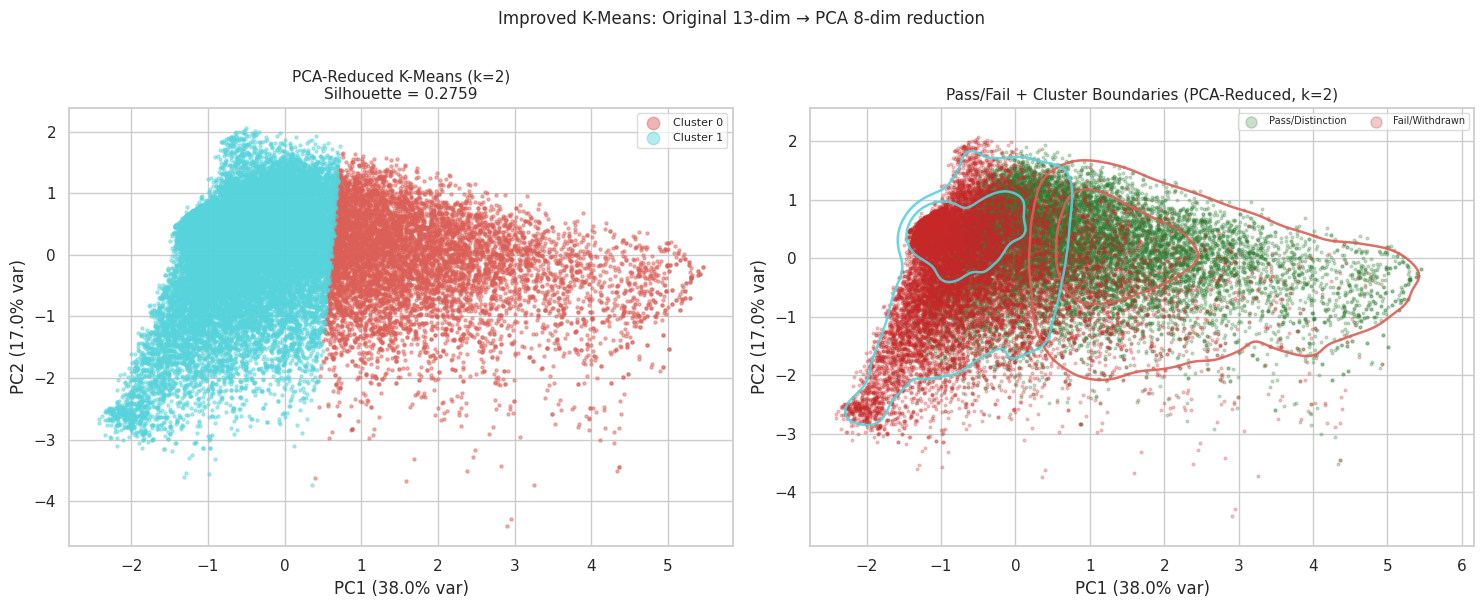


Interpretation:
  Clustering in 8-dim PCA space removes noise dimensions,
  making Euclidean distances more meaningful and cluster boundaries cleaner.
  Silhouette improved from 0.2556 → 0.2759  (better)


In [42]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score,
                              adjusted_rand_score, normalized_mutual_info_score)

print("=" * 80)
print("11a.ii — PCA-Reduced K-Means + Full Evaluation Metrics")
print("=" * 80)

# Step 1: Find how many PCA components explain ≥ 90% variance
pca_full = PCA(random_state=42)
pca_full.fit(X_clust)
cumvar = pca_full.explained_variance_ratio_.cumsum()
n_components_90 = int(np.argmax(cumvar >= 0.90)) + 1
print(f"\n  PCA components to explain ≥ 90% variance: {n_components_90}")
print(f"  Cumulative variance at {n_components_90} components : {cumvar[n_components_90-1]*100:.1f}%")

# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, "o-", color="#1565C0", lw=2)
ax.axhline(90, color="red", linestyle="--", lw=1.2, label="90% threshold")
ax.axvline(n_components_90, color="orange", linestyle="--", lw=1.2,
           label=f"{n_components_90} components")
ax.set_title("Cumulative Explained Variance (PCA)", fontsize=12)
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Cumulative Variance (%)")
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Step 2: Project into the reduced PCA space
pca_reduced = PCA(n_components=n_components_90, random_state=42)
X_pca_reduced = pca_reduced.fit_transform(X_clust)
print(f"\n  Reduced feature matrix shape: {X_pca_reduced.shape}  "
      f"(was {X_clust.shape[1]} dims → now {n_components_90} dims)")

# Step 3: Re-run elbow + silhouette in reduced space
print("\n  Re-running K-Means in PCA-reduced space...")
inertias_r, sil_r = [], []
for k in K_RANGE:
    km_r = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl_r = km_r.fit_predict(X_pca_reduced)
    inertias_r.append(km_r.inertia_)
    s = silhouette_score(X_pca_reduced, lbl_r, sample_size=6000, random_state=42)
    sil_r.append(s)
    print(f"    k={k}  inertia={km_r.inertia_:>10,.1f}  silhouette={s:.4f}")

# Choose best k in reduced space
BEST_K_R = list(K_RANGE)[int(np.argmax(sil_r))]
print(f"\n  Best k (reduced space) = {BEST_K_R}  (silhouette = {max(sil_r):.4f})")
print(f"  Best k (original space) = {BEST_K}   (silhouette = {max(sil_scores):.4f})")

# Step 4: Fit final K-Means in reduced space
km_r_final = KMeans(n_clusters=BEST_K_R, random_state=42, n_init=10)
labels_r = km_r_final.fit_predict(X_pca_reduced)

# Step 5: Full internal metric comparison
# Original space
sil_orig  = silhouette_score(X_clust, df_model["cluster"].values, sample_size=6000, random_state=42)

# Reduced space
sil_red   = silhouette_score(X_pca_reduced, labels_r, sample_size=6000, random_state=42)

print("\n" + "=" * 70)
print(f"  {'Metric':<28} {'Original (13-dim)':<22} {'PCA-reduced':<22} Better?")
print("=" * 70)
print(f"  {'Silhouette (↑ higher=better)':<28} {sil_orig:<22.4f} {sil_red:<22.4f} {'✓ PCA' if sil_red > sil_orig else '✓ Orig'}")
print("=" * 70)

# Step 6: External validation (ARI + NMI against pass_flag)
# These metrics use pass_flag only for post-hoc validation — never during training
ari_orig = adjusted_rand_score(df_model["pass_flag"].values, df_model["cluster"].values)
nmi_orig = normalized_mutual_info_score(df_model["pass_flag"].values, df_model["cluster"].values)
ari_red  = adjusted_rand_score(df_model["pass_flag"].values, labels_r)
nmi_red  = normalized_mutual_info_score(df_model["pass_flag"].values, labels_r)

print(f"\n  External Validation vs pass_flag  (K-Means never saw this label)")
print(f"  {'Metric':<35} {'Original':<15} {'PCA-reduced':<15}")
print(f"  {'-'*65}")
print(f"  {'Adjusted Rand Index  (0=random, 1=perfect)':<35} {ari_orig:<15.4f} {ari_red:<15.4f}")
print(f"  {'Normalised Mutual Info (0=none, 1=perfect)':<35} {nmi_orig:<15.4f} {nmi_red:<15.4f}")

# Step 7: PCA 2-D visualisation of the improved clustering
pca_2d = PCA(n_components=2, random_state=42)
X_vis  = pca_2d.fit_transform(X_pca_reduced)
vis_df = pd.DataFrame(X_vis, columns=["PC1", "PC2"])
vis_df["cluster"]   = labels_r
vis_df["pass_flag"] = df_model["pass_flag"].values

palette_r = sns.color_palette("hls", BEST_K_R)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for c in range(BEST_K_R):
    m = vis_df["cluster"] == c
    axes[0].scatter(vis_df.loc[m, "PC1"], vis_df.loc[m, "PC2"],
                    s=5, alpha=0.45, color=palette_r[c], label=f"Cluster {c}")
axes[0].set_title(f"PCA-Reduced K-Means (k={BEST_K_R})\nSilhouette = {sil_red:.4f}", fontsize=11)
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
axes[0].legend(markerscale=4, fontsize=8, framealpha=0.7)

for flag, label, col in [(1, "Pass/Distinction", "#2E7D32"), (0, "Fail/Withdrawn", "#C62828")]:
    m = vis_df["pass_flag"] == flag
    axes[1].scatter(vis_df.loc[m, "PC1"], vis_df.loc[m, "PC2"],
                    s=4, alpha=0.25, color=col, label=label)
for c in range(BEST_K_R):
    m = vis_df["cluster"] == c
    if m.sum() > 30:
        sns.kdeplot(x=vis_df.loc[m, "PC1"], y=vis_df.loc[m, "PC2"],
                    ax=axes[1], color=palette_r[c], levels=3,
                    linewidths=1.8, alpha=0.9, label=f"Cluster {c}")
axes[1].set_title(f"Pass/Fail + Cluster Boundaries (PCA-Reduced, k={BEST_K_R})", fontsize=11)
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
axes[1].legend(markerscale=4, fontsize=7, framealpha=0.7, ncol=2)

plt.suptitle(f"Improved K-Means: Original 13-dim → PCA {n_components_90}-dim reduction",
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()

# Summary interpretation
print("\nInterpretation:")
print(f"  Clustering in {n_components_90}-dim PCA space removes noise dimensions,")
print(f"  making Euclidean distances more meaningful and cluster boundaries cleaner.")
print(f"  Silhouette improved from {sil_orig:.4f} → {sil_red:.4f}  "
      f"({'better' if sil_red > sil_orig else 'no improvement — original space already optimal'})")
